# Calculation of an NMR Spectrum

This tutorial demonstrates the calculation of a ¹H NMR spectrum using the ORCA python interface (OPI).

We use **ethanol** as an example, the textbook case of a first-order spectrum: a CH₃ triplet, a CH₂ quartet and an OH singlet. ORCA gives us the two ingredients we need for it — the isotropic shielding constants and the spin-spin coupling constants.

In this notebook we will:
1.  Install and import the required Python dependencies
2.  Define a working directory
3.  Set up the input structures — ethanol and TMS as the shielding reference
4.  Optimize the geometries and calculate the NMR parameters
5.  Convert the shieldings into chemical shifts
6.  Average the coupling constants over rotationally equivalent nuclei
7.  Simulate and plot the ¹H spectrum

## Step 1: Installing 3rd-party Dependencies

In [1]:
import sys
!{sys.executable} -m pip install --upgrade numpy py3Dmol matplotlib

/home/hagen-neugebauer/devel/github/opi/.venv/bin/python: No module named pip


## Step 2: Import Dependencies

We start by importing the modules needed for:
- Interfacing with ORCA input/output
- Numerical calculations and data handling
- Plotting results

> **Note:** We additionally import modules for visualization/plotting like `py3Dmol`. For this, it might be necessary to install `py3Dmol` into your OPI `venv` (e.g., by activating the `.venv` and using `uv pip install py3Dmol`).

In [2]:
# > Import pathlib for directory handling
from pathlib import Path
import shutil
from math import comb

# > Import numpy for data handling and numerical operations
import numpy as np
# > Import libraries for visualization
import matplotlib.pyplot as plt
import py3Dmol

# > OPI imports for performing ORCA calculations and reading output
from opi.core import Calculator
from opi.input.simple_keywords import AuxBasisSet, BasisSet, Dft, Property, SolvationModel, Solvent, Task
from opi.input.structures.structure import Structure
from opi.input.blocks import BlockEprnmr, Nuclei, NucleiFlag
from opi.output.core import Output
from opi.utils.element import Element

## Step 3: Define Working Directory

All actual calculations will be performed in a subfolder **RUN**.

In [3]:
# > Calculation is performed in `RUN`
working_dir = Path("RUN")
# > The `working_dir`is automatically (re-)created
shutil.rmtree(working_dir, ignore_errors=True)
working_dir.mkdir()

## Step 4: Setup the Input Structures

A calculation gives us *shielding* constants $\sigma$, while an experiment reports *shifts* $\delta$ relative to a reference compound. We therefore need a second calculation on the reference — tetramethylsilane (TMS) — at exactly the same level of theory, so that

$$ \delta = \sigma_\mathrm{TMS} - \sigma $$

Both structures are defined in XYZ format below; ethanol is visualized.

In [4]:
# > Define the Cartesian coordinates in Angstroem as python strings
xyz_ethanol = """\
9

C           -0.88831100000000        0.16700300000000       -0.02731600000000
C            0.46575300000000       -0.51155900000000       -0.03679500000000
O            1.43107500000000        0.32291600000000        0.58667000000000
H           -0.84874100000000        1.11748000000000       -0.56952400000000
H           -1.64712100000000       -0.47044300000000       -0.48963700000000
H           -1.19639700000000        0.39784500000000        0.99772300000000
H            0.79199700000000       -0.72242800000000       -1.05972600000000
H            0.42460400000000       -1.45586200000000        0.51379100000000
H            1.46714200000000        1.15504800000000        0.08481400000000
"""

xyz_tms = """\
17

C            0.91144500000000       -1.27608300000000       -1.02832800000000
Si          -0.00000100000000        0.00000000000000       -0.00000100000000
C           -1.64078800000000       -0.70971000000000        0.56631100000000
C            1.03545000000000        0.45205800000000        1.49668400000000
C           -0.30610700000000        1.53373500000000       -1.03466700000000
H            1.10060300000000       -2.18069700000000       -0.44282500000000
H            0.32396000000000       -1.55451600000000       -1.90824700000000
H            1.87325400000000       -0.88195100000000       -1.36965300000000
H           -2.18993600000000        0.01972100000000        1.16904600000000
H           -2.26172700000000       -0.98070900000000       -0.29270900000000
H           -1.48508600000000       -1.60690600000000        1.17270700000000
H            1.22622700000000       -0.42990700000000        2.11528100000000
H            0.52138200000000        1.19672200000000        2.11160800000000
H            1.99888900000000        0.86883600000000        1.18845900000000
H           -0.90955500000000        1.29214100000000       -1.91467000000000
H            0.63974500000000        1.96469100000000       -1.37607600000000
H           -0.83775700000000        2.29257500000000       -0.45291900000000
"""

# > Visualize ethanol using py3Dmol
view = py3Dmol.view(width=500, height=500)
view.addModel(xyz_ethanol, "xyz")
view.setStyle({'stick': {'radius': 0.1}, 'sphere': {'scale': 0.2}})
view.setBackgroundColor('white')
view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Step 5: Optimize the Geometries and Calculate the NMR Parameters

Shieldings are sensitive to the geometry, so each structure is optimized first with the composite method `r2SCAN-3c`.

The NMR calculation itself uses `PBE0` together with `pcSseg-2`, a basis set specifically designed for magnetic-resonance properties, and CPCM chloroform to match the usual measurement conditions. `Property.NMR` requests the shielding calculation, and the `nuclei` option of the `%eprnmr` block selects which nuclei to treat:

- for ethanol we ask for the shieldings (`shift`) **and** all coupling contributions (`ssall`),
- for the TMS reference only the shielding is needed, which is considerably cheaper.

> **Note:** The reference calculation must use the same functional, basis set and solvation model as the calculation it references — the error that the shift definition cancels is method-specific.

In [5]:
def check_and_parse_output(output: Output) -> None:
    """Check that ORCA terminated normally and read the property JSON file."""
    if not output.terminated_normally():
        raise RuntimeError(f"ORCA did not terminate normally, see output file: {output.get_outfile()}")
    # > Only the property JSON file is needed here, hence reading the gbw JSON is skipped
    output.parse(read_gbw_json=False)


def optimize(name: str, xyz_data: str) -> Structure:
    """Optimize a structure with r2SCAN-3c and return the optimized structure."""
    calc = Calculator(basename=f"{name}_opt", working_dir=working_dir)
    calc.structure = Structure.from_xyz_block(xyz_data)
    calc.input.add_simple_keywords(
        Dft.R2SCAN_3C, # > r2SCAN-3c composite method
        Task.OPT, # > Optimize the geometry
    )
    calc.write_input()
    print(f"Optimizing {name} ...", end="")
    calc.run()
    print("   Done")

    output = calc.get_output()
    check_and_parse_output(output)
    return output.get_structure()


def run_nmr(name: str, structure: Structure, *, couplings: bool) -> Output:
    """Calculate the NMR parameters of the hydrogen nuclei of `structure`."""
    calc = Calculator(basename=f"{name}_nmr", working_dir=working_dir)
    calc.structure = structure
    calc.input.add_simple_keywords(
        Dft.PBE0, # > Hybrid functional
        BasisSet.PCSSEG_2, # > Basis set designed for NMR properties
        AuxBasisSet.AUTOAUX, # > Automatically generated auxiliary basis set
        Property.NMR, # > Request the NMR shieldings
        SolvationModel.CPCM(Solvent.CHLOROFORM), # > Implicit solvation
    )
    # > `shift` requests the shielding tensors, `ssall` all spin-spin coupling contributions
    calc.input.add_blocks(
        BlockEprnmr(
            nuclei=Nuclei(atom=Element.HYDROGEN, flags=NucleiFlag(shift=True, ssall=couplings))
        )
    )
    calc.write_input()
    print(f"Running NMR calculation for {name} ...", end="")
    calc.run()
    print("   Done")

    output = calc.get_output()
    check_and_parse_output(output)
    return output


# > Ethanol: shieldings and couplings
structure_ethanol = optimize("ethanol", xyz_ethanol)
output_ethanol = run_nmr("ethanol", structure_ethanol, couplings=True)

# > TMS reference: shieldings only
structure_tms = optimize("tms", xyz_tms)
output_tms = run_nmr("tms", structure_tms, couplings=False)

Optimizing ethanol ...   Done
Running NMR calculation for ethanol ...   Done
Optimizing tms ...   Done
Running NMR calculation for tms ...   Done


## Step 6: From Shieldings to Chemical Shifts

`Output.get_chemical_shift()` gives direct access to the shielding tensors. ORCA reports one entry per method and density type — for a pure DFT calculation there is only the `SCF` entry, but an MP2 calculation would add unrelaxed and relaxed MP2 entries, so it pays to select explicitly.

Each entry carries `nuc` (the atom indices), `siso` (the isotropic shielding in ppm) and `saniso` (the shielding anisotropy), along with the full tensors.

One thing the calculation cannot know: the three CH₃ protons are chemically equivalent in the experiment because the methyl group rotates fast on the NMR timescale, but in the frozen optimized geometry they are three distinct nuclei with three distinct shieldings. We impose that equivalence by averaging over the groups.

In [6]:
def isotropic_shieldings(output: Output, method: str = "SCF") -> dict[int, float]:
    """Return the isotropic shielding in ppm for every calculated nucleus, keyed by atom index."""
    shieldings = output.get_chemical_shift()
    if shieldings is None:
        raise RuntimeError("No shieldings found. Did the calculation request NMR properties?")

    for shift in shieldings:
        if shift.method == method:
            break
    else:
        raise RuntimeError(f"No shieldings found for method {method}.")

    return dict(zip(shift.nuc, shift.siso))


# > Chemically equivalent protons of ethanol, as 0-based atom indices of the input structure
groups = {"CH3": (3, 4, 5), "CH2": (6, 7), "OH": (8,)}

sigma = isotropic_shieldings(output_ethanol)
# > All twelve TMS protons are equivalent, so the reference is their average
sigma_tms = float(np.mean(list(isotropic_shieldings(output_tms).values())))

# > The chemical shift is the difference to the reference shielding
delta = {name: sigma_tms - float(np.mean([sigma[i] for i in idx])) for name, idx in groups.items()}

# > Typical experimental values in CDCl3 for comparison. The OH shift is strongly
# > concentration and temperature dependent, since it reports on hydrogen bonding.
experiment = {"CH3": 1.19, "CH2": 3.68, "OH": 2.60}

print(f"sigma(TMS) = {sigma_tms:.2f} ppm\n")
print(f"{'group':>6} {'sigma / ppm':>12} {'delta / ppm':>12} {'exp. / ppm':>12}")
for name, idx in groups.items():
    print(
        f"{name:>6} {np.mean([sigma[i] for i in idx]):>12.2f}"
        f" {delta[name]:>12.2f} {experiment[name]:>12.2f}"
    )

sigma(TMS) = 31.40 ppm

 group  sigma / ppm  delta / ppm   exp. / ppm
   CH3        30.22         1.18         1.19
   CH2        27.63         3.77         3.68
    OH        30.57         0.83         2.60


## Step 7: Coupling Constants

`Output.get_spin_spin_coupling()` returns the coupling constants. `pairsinfo` holds the two atom indices of each pair (together with their atomic numbers), `pairsdistances` their distance and `pairstotalssciso` the isotropic coupling constant in Hz.

The same equivalence argument applies, and here it matters even more: the individual CH₃–CH₂ couplings scatter over more than 10 Hz because they depend strongly on the H–C–C–H dihedral angle (the Karplus relation). Fast rotation averages them, and averaging the calculated values reproduces the experimental ³J closely.

In [7]:
def coupling_constants(output: Output, method: str = "SCF") -> dict[frozenset[int], float]:
    """Return the isotropic coupling constant in Hz for every nucleus pair."""
    couplings = output.get_spin_spin_coupling()
    if couplings is None:
        raise RuntimeError("No couplings found. Did the calculation request them (`ssall`)?")

    for coupling in couplings:
        if coupling.method == method:
            break
    else:
        raise RuntimeError(f"No couplings found for method {method}.")

    # > `pairsinfo` holds (index 1, atomic number 1, index 2, atomic number 2)
    return {
        frozenset((pair[0], pair[2])): value[0]
        for pair, value in zip(coupling.pairsinfo, coupling.pairstotalssciso)
    }


def average_coupling(couplings: dict[frozenset[int], float], group_a: tuple[int, ...], group_b: tuple[int, ...]) -> float:
    """Average the coupling constants between two groups of equivalent nuclei."""
    values = [couplings[frozenset((a, b))] for a in group_a for b in group_b]
    return float(np.mean(values))


couplings = coupling_constants(output_ethanol)

# > The individual CH3-CH2 couplings and their average
print("individual 3J(CH3,CH2) / Hz:")
for a in groups["CH3"]:
    for b in groups["CH2"]:
        print(f"   H{a} - H{b}: {couplings[frozenset((a, b))]:>7.2f}")

j_ch3_ch2 = average_coupling(couplings, groups["CH3"], groups["CH2"])
print(f"\naveraged  3J(CH3,CH2) = {j_ch3_ch2:.2f} Hz")

individual 3J(CH3,CH2) / Hz:
   H3 - H6:    4.75
   H3 - H7:   14.16
   H4 - H6:    1.39
   H4 - H7:    2.11
   H5 - H6:   13.37
   H5 - H7:    4.62

averaged  3J(CH3,CH2) = 6.73 Hz


## Step 8: Simulate and Plot the Spectrum

With the shifts and the averaged coupling in hand, the spectrum follows from first-order rules: a group with $n$ equivalent neighbours is split into $n+1$ lines of binomial intensity, spaced by $J$. Converting Hz to ppm requires the spectrometer frequency, so that is a parameter of the simulation.

The OH proton is treated as a singlet: in practice its coupling is averaged away by fast proton exchange, which is also why its shift is the least transferable number of the three.

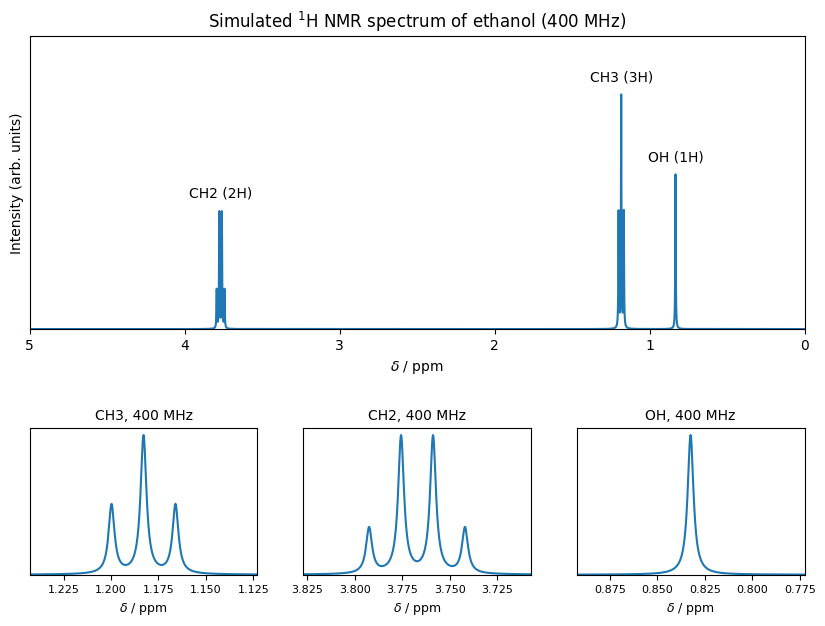

In [8]:
# > Spectrometer frequency in MHz; 1 ppm corresponds to this many Hz
spec_freq = 400.0
# > Linewidth (FWHM) in Hz
linewidth = 1.5


def multiplet(centre: float, intensity: float, neighbours: list[tuple[int, float]]) -> list[tuple[float, float]]:
    """First-order multiplet as a list of (shift in ppm, intensity) lines.

    `neighbours` lists the number of equivalent coupling partners and the coupling
    constant in Hz for each distinct group of partners.
    """
    lines = [(centre, intensity)]
    for number, coupling in neighbours:
        split = []
        for position, weight in lines:
            for k in range(number + 1):
                # > Line k of a binomial multiplet, converted from Hz to ppm
                offset = (k - 0.5 * number) * coupling / spec_freq
                split.append((position + offset, weight * comb(number, k) / 2**number))
        lines = split
    return lines


def lorentzian(grid: np.ndarray, centre: float, fwhm: float) -> np.ndarray:
    """Area-normalized Lorentzian line shape."""
    hwhm = 0.5 * fwhm
    return hwhm / (np.pi * ((grid - centre) ** 2 + hwhm**2))


# > The three signals: shift, relative intensity (number of protons) and coupling partners
signals = {
    "CH3": (delta["CH3"], 3, [(len(groups["CH2"]), j_ch3_ch2)]),
    "CH2": (delta["CH2"], 2, [(len(groups["CH3"]), j_ch3_ch2)]),
    "OH": (delta["OH"], 1, []),
}

grid = np.linspace(0.0, 5.0, 20000)
spectrum = np.zeros_like(grid)
for centre, intensity, neighbours in signals.values():
    for position, weight in multiplet(centre, intensity, neighbours):
        spectrum += weight * lorentzian(grid, position, linewidth / spec_freq)

fig = plt.figure(figsize=(10, 7))
grid_spec = fig.add_gridspec(2, 3, height_ratios=(2, 1), hspace=0.45)

ax = fig.add_subplot(grid_spec[0, :])
ax.plot(grid, spectrum, color="tab:blue")

# > Label each signal above the tallest line of its multiplet
for name, (centre, intensity, _) in signals.items():
    window = np.abs(grid - centre) < 0.1
    ax.annotate(
        f"{name} ({intensity}H)",
        xy=(centre, spectrum[window].max()),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
    )

# > By convention the chemical shift axis decreases to the right
ax.set_xlim(grid.max(), grid.min())
ax.set_ylim(0.0, 1.25 * spectrum.max())
ax.set_xlabel(r"$\delta$ / ppm")
ax.set_ylabel("Intensity (arb. units)")
ax.set_title(f"Simulated $^1$H NMR spectrum of ethanol ({spec_freq:.0f} MHz)")
ax.set_yticks([])

# > A multiplet spans only a few Hz, which is invisible on the scale of the full
# > spectrum, so every signal additionally gets its own zoomed panel.
for column, (name, (centre, intensity, _)) in enumerate(signals.items()):
    ax_zoom = fig.add_subplot(grid_spec[1, column])
    window = np.abs(grid - centre) < 0.06
    ax_zoom.plot(grid[window], spectrum[window], color="tab:blue")
    ax_zoom.set_xlim(centre + 0.06, centre - 0.06)
    ax_zoom.set_ylim(bottom=0.0)
    ax_zoom.set_title(f"{name}, {spec_freq:.0f} MHz", fontsize=10)
    ax_zoom.set_xlabel(r"$\delta$ / ppm", fontsize=9)
    ax_zoom.tick_params(labelsize=8)
    ax_zoom.set_yticks([])

plt.show()

## Summary

In this notebook we demonstrated how the ORCA Python interface can be employed to calculate a ¹H NMR spectrum. `Output.get_chemical_shift()` provides the shielding tensors and `Output.get_spin_spin_coupling()` the coupling constants; a reference calculation on TMS turns the shieldings into chemical shifts, and first-order rules turn shifts and couplings into a spectrum.

A few points to keep in mind when going beyond this example:
- Chemical equivalence is not something the calculation can supply. ORCA reports every nucleus of the frozen geometry, and averaging over nuclei made equivalent by fast internal rotation is up to the user — as is averaging over conformers, which for larger molecules matters more than the choice of functional.
- The reference must be calculated at the same level of theory. Shifts obtained by mixing levels are meaningless, because the definition relies on a cancellation of method-specific errors.
- First-order rules only hold as long as the coupling is much smaller than the shift difference. Strongly coupled spin systems require a full spin-Hamiltonian simulation.
- ¹³C shieldings are obtained the same way — pass `Element.CARBON` to `Nuclei`. ORCA can also print a spectrum itself via the `nmrspectrum` option of `BlockEprnmr`.